<p class="h1">ECE 447 - Notebook 14</p>
<p class="h2">Unpservised Learning II</p>

This notebook shows how to:

- load **MNIST** or **CIFAR-10**
- preprocess and subsample the data
- compute **PCA**, **NMF**, and **sparse coding**
- visualize learned atoms

In [ ]:
# If needed, install the required packages in your environment:
# !pip install numpy matplotlib scikit-learn torch torchvision

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, NMF, DictionaryLearning
from sklearn.preprocessing import StandardScaler

import  torchvision

## Helper functions

In [47]:
def load_dataset(name="mnist", n_samples=5000, random_state=0, cifar_to_grayscale=False):
    """
    Load MNIST or CIFAR-10 from torchvision and return:
        X: flattened data matrix, shape [n_samples, n_features]
        y: labels
        images: unflattened images for visualization
        class_names: list of class names
    """
    rng = np.random.default_rng(random_state)

    if name.lower() == "mnist":
        transform = torchvision.transforms.ToTensor()
        ds = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

        idx = rng.choice(len(ds), size=n_samples, replace=False)
        images = []
        labels = []
        for i in idx:
            img, label = ds[i]                  # img: [1, 28, 28], in [0,1]
            images.append(img.squeeze(0).numpy())
            labels.append(label)

        images = np.stack(images, axis=0)      # [N, 28, 28]
        X = images.reshape(len(images), -1)
        y = np.array(labels)
        class_names = [str(i) for i in range(10)]
        return X, y, images, class_names

    elif name.lower() == "cifar10":
        if cifar_to_grayscale:
            transform = torchvision.transforms.Compose([
                torchvision.transforms.Grayscale(num_output_channels=1),
                torchvision.transforms.ToTensor()
            ])
        else:
            transform = torchvision.transforms.ToTensor()

        ds = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)

        idx = rng.choice(len(ds), size=n_samples, replace=False)
        images = []
        labels = []
        for i in idx:
            img, label = ds[i]
            images.append(img.numpy())
            labels.append(label)

        images = np.stack(images, axis=0)
        y = np.array(labels)
        class_names = ds.classes

        if cifar_to_grayscale:
            # images shape: [N, 1, 32, 32]
            X = images.reshape(len(images), -1)
            images_for_plot = images[:, 0]     # [N, 32, 32]
        else:
            # images shape: [N, 3, 32, 32]
            X = images.reshape(len(images), -1)
            images_for_plot = np.transpose(images, (0, 2, 3, 1))  # [N, 32, 32, 3]

        return X, y, images_for_plot, class_names

    else:
        raise ValueError("Dataset must be 'mnist' or 'cifar10'.")


def show_samples(images, labels, class_names, n=16, title="Sample images"):
    plt.figure(figsize=(10, 6))
    inds = np.random.choice(len(images), size=n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    for j, i in enumerate(inds, 1):
        plt.subplot(rows, cols, j)
        img = images[i]
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_2d_embedding(Z, labels, class_names=None, title="2D embedding"):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(Z[:, 0], Z[:, 1], c=labels, s=8, alpha=0.7)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.title(title)
    if class_names is not None and len(class_names) <= 10:
        cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
        cbar.ax.set_yticklabels(class_names)
    else:
        plt.colorbar(scatter)
    plt.tight_layout()
    plt.show()


def show_atoms(components, image_shape, n_show=16, title="Components / dictionary vectors", cmap="gray"):
    """
    Visualize PCA/NMF/dictionary atoms.
    image_shape should be e.g. (28,28), (32,32), or (32,32,3)
    """
    n_show = min(n_show, len(components))
    cols = 4
    rows = int(np.ceil(n_show / cols))
    plt.figure(figsize=(10, 8))
    for i in range(n_show):
        plt.subplot(rows, cols, i + 1)
        comp = components[i]
        img = comp.reshape(image_shape)

        if len(image_shape) == 2:
            plt.imshow(img, cmap=cmap)
        else:
            # For RGB display, normalize each component image to [0,1] for visualization
            img = img - img.min()
            if img.max() > 0:
                img = img / img.max()
            plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## Load data

### Configuration

- `DATASET`: `"mnist"` or `"cifar10"`
- `N_SAMPLES`: number of examples to use
- `RANDOM_STATE`: for reproducibility

X shape: (5000, 784)
y shape: (5000,)
Pixel range: 0.0 to 1.0


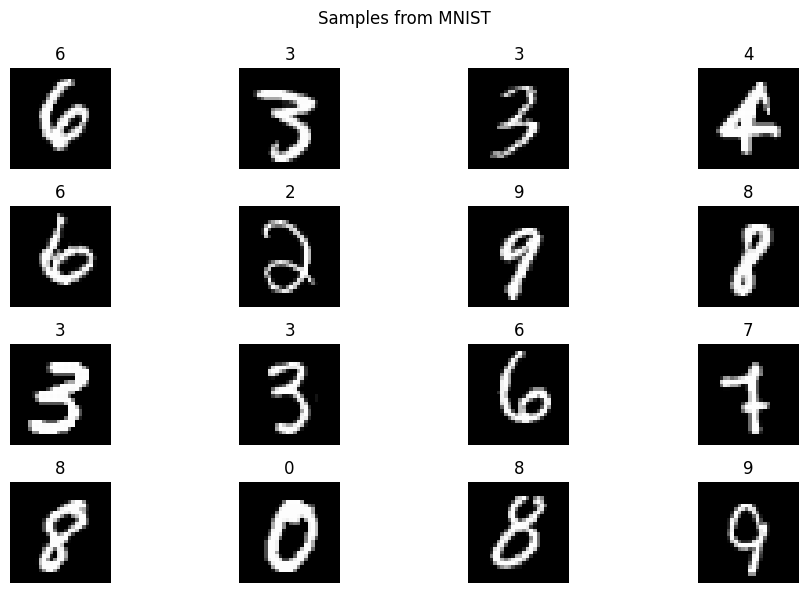

In [ ]:
DATASET = "mnist"      # choose: "mnist" or "cifar10"
N_SAMPLES = 5000       # reduce/increase depending on your machine
RANDOM_STATE = 0

np.random.seed(RANDOM_STATE)

X, y, images, class_names = load_dataset(
    name=DATASET,
    n_samples=N_SAMPLES,
    random_state=RANDOM_STATE,
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Pixel range:", X.min(), "to", X.max())

show_samples(images, y, class_names, n=16, title=f"Samples from {DATASET.upper()}")


## Optional preprocessing

For **PCA**, standardization is often helpful.  
For **NMF**, inputs must remain **nonnegative**, so we use the raw pixel values.  
For **sparse coding**, both centered/scaled and raw variants can be useful; here we standardize.


In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data mean (approx):", X_scaled.mean())
print("Scaled data std (approx):", X_scaled.std())


Scaled data mean (approx): -1.5570192e-10
Scaled data std (approx): 0.91403455


## 1) PCA

We compute a low-dimensional linear representation and visualize the first two principal directions.


PCA embedding shape: (5000, 50)
Explained variance ratio (first 10):
[0.062  0.0441 0.0412 0.0325 0.0285 0.023  0.0205 0.0192 0.0174 0.0153]
Cumulative explained variance (50 comps): 0.61298966


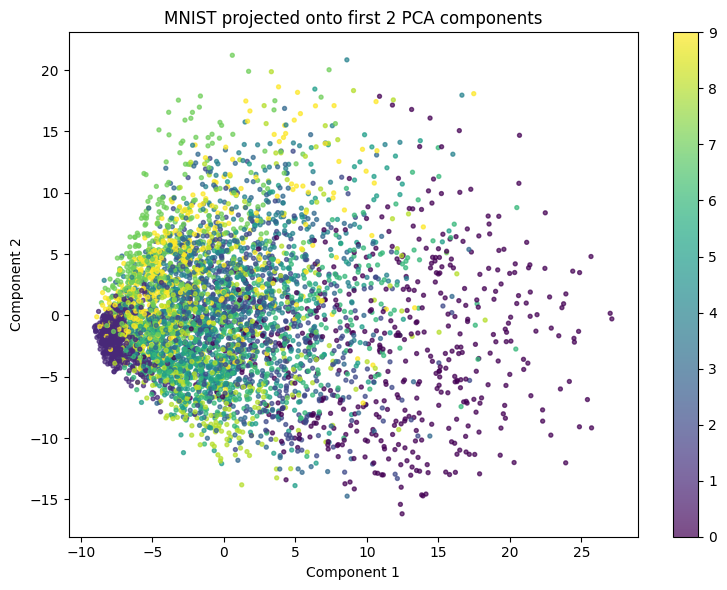

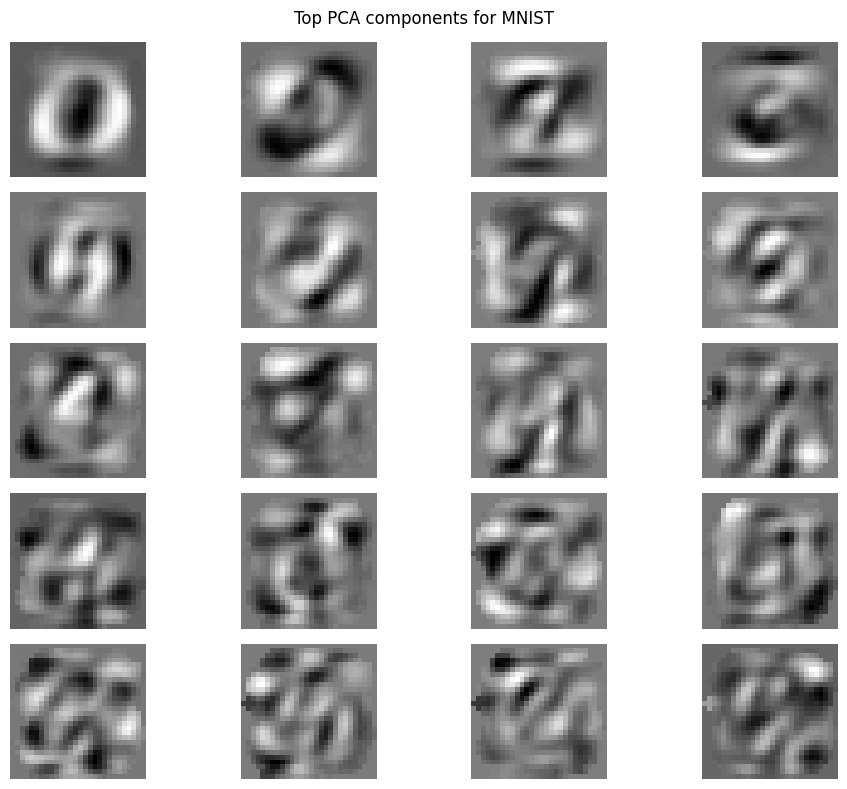

In [50]:
N_PCA_COMPONENTS = 50

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_STATE)
Z_pca = pca.fit_transform(X_scaled)

print("PCA embedding shape:", Z_pca.shape)
print("Explained variance ratio (first 10):")
print(np.round(pca.explained_variance_ratio_[:10], 4))
print("Cumulative explained variance (50 comps):", np.sum(pca.explained_variance_ratio_))

plot_2d_embedding(Z_pca[:, :2], y, class_names, title=f"{DATASET.upper()} projected onto first 2 PCA components")

# Visualize leading PCA directions / eigenvectors
if DATASET == "mnist":
    image_shape = (28, 28)
elif DATASET == "cifar10" and CIFAR_TO_GRAYSCALE:
    image_shape = (32, 32)
else:
    image_shape = (32, 32, 3)

show_atoms(
    pca.components_,
    image_shape=image_shape,
    n_show=20,
    title=f"Top PCA components for {DATASET.upper()}",
    cmap="gray"
)

## 3) NMF

NMF requires **nonnegative** data, so we fit it on the raw pixel matrix `X`, not the standardized one.

For images, NMF often gives more parts-based representations than PCA.


NMF code shape: (5000, 25)
NMF dictionary shape: (25, 784)


/Users/toloosha/miniconda3/envs/ece447/lib/python3.14/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 300 reached. Increase it to improve convergence.
  warnings.warn(


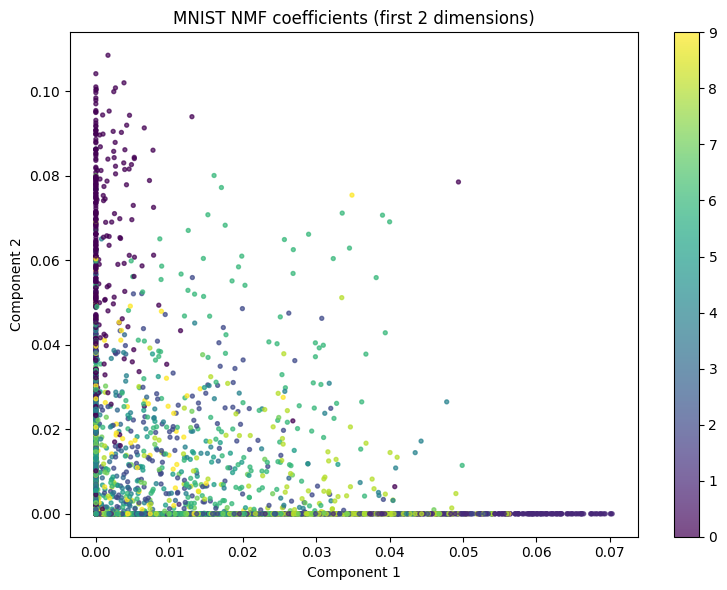

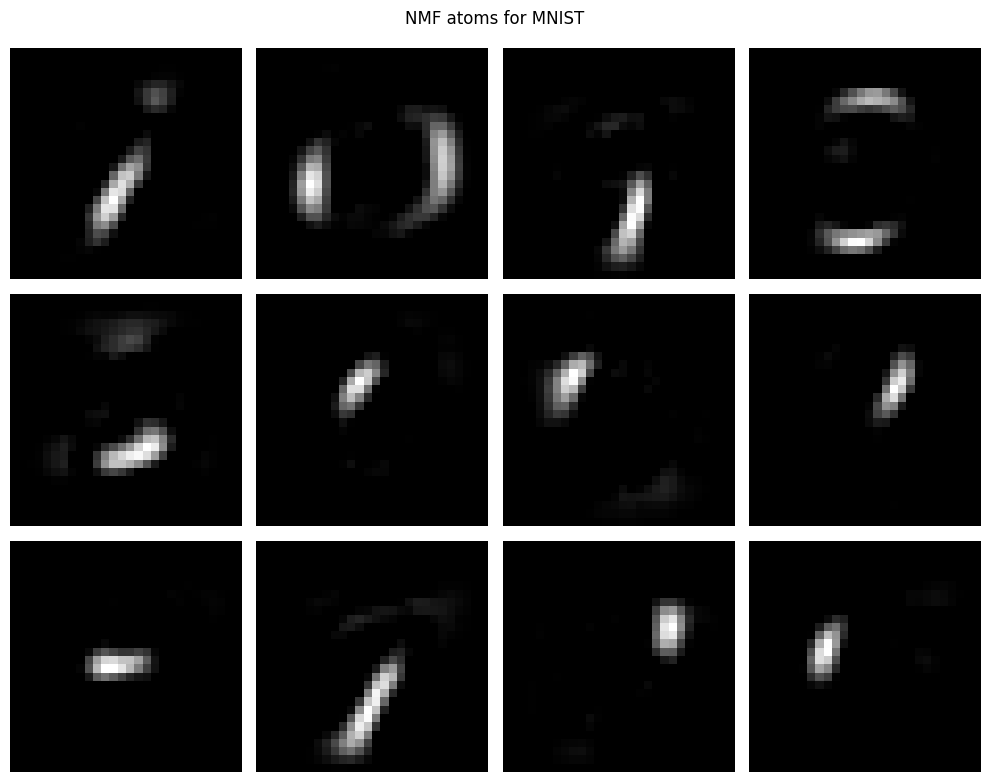

In [51]:
N_NMF_COMPONENTS = 25

nmf = NMF(
    n_components=N_NMF_COMPONENTS,
    init="nndsvda",
    random_state=RANDOM_STATE,
    max_iter=300
)
Z_nmf = nmf.fit_transform(X)
H_nmf = nmf.components_

print("NMF code shape:", Z_nmf.shape)
print("NMF dictionary shape:", H_nmf.shape)

plot_2d_embedding(Z_nmf[:, :2], y, class_names, title=f"{DATASET.upper()} NMF coefficients (first 2 dimensions)")

show_atoms(
    H_nmf,
    image_shape=image_shape,
    n_show=12,
    title=f"NMF atoms for {DATASET.upper()}",
    cmap="gray"
)

## 4) Sparse coding / dictionary learning

We use `DictionaryLearning` from scikit-learn.

- The learned dictionary atoms can be visualized.
- The transformed coefficients are sparse codes.

For DL, there are more efficient libraries (in PyTorch) which can be used. sklearn is slow and not scalable, hence, below we try it on a small porition of data.


/Users/toloosha/miniconda3/envs/ece447/lib/python3.14/site-packages/sklearn/linear_model/_least_angle.py:753: ConvergenceWarning: Early stopping the lars path, as the residues are small and the current value of alpha is no longer well controlled. 24 iterations, alpha=4.033e-04, previous alpha=4.030e-04, with an active set of 25 regressors.
  warnings.warn(


lambda for sparsity is 0.01
Sparse code shape: (2000, 32)
Dictionary shape: (32, 784)
Average number of non-zero coefficients per sample: 31.695


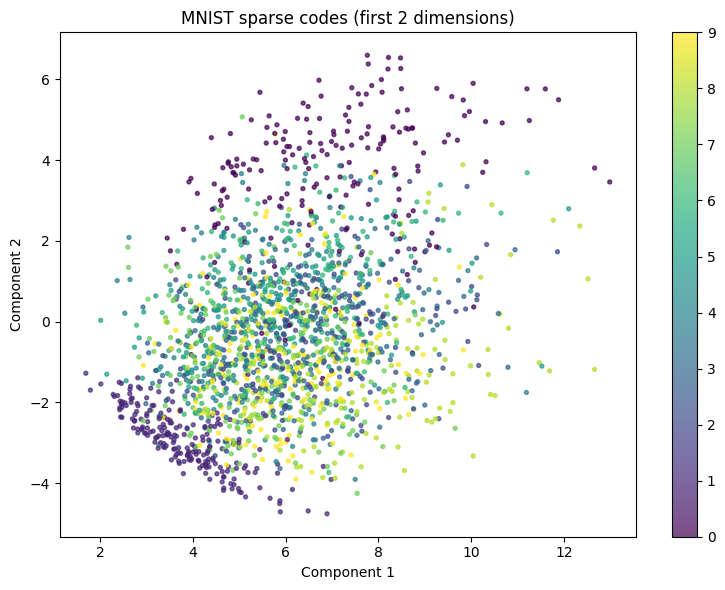

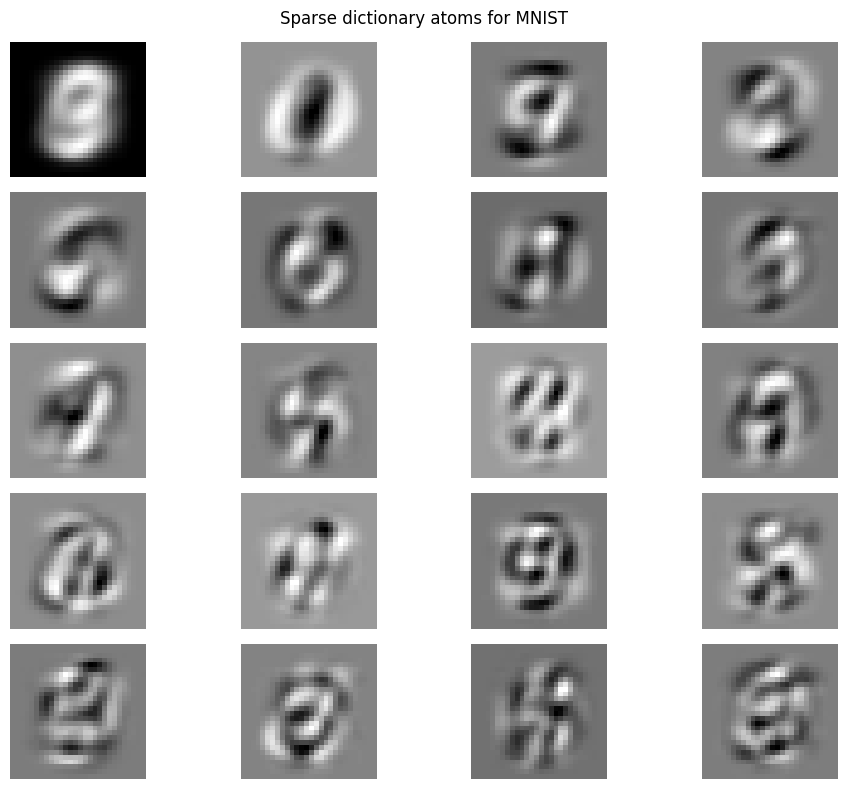

In [64]:
N_DICT_COMPONENTS = 32

alpha = 0.01
dict_learner = DictionaryLearning(
    n_components=N_DICT_COMPONENTS,
    transform_algorithm="lasso_lars",
    alpha=alpha,
    random_state=RANDOM_STATE,
    max_iter=20
)

mini = 2000
X_mini = X[:mini,:]
y_mini = y[:mini]
Z_sparse = dict_learner.fit_transform(X_mini)
D_sparse = dict_learner.components_

print("lambda for sparsity is", alpha)
print("Sparse code shape:", Z_sparse.shape)
print("Dictionary shape:", D_sparse.shape)
print("Average number of non-zero coefficients per sample:",
      np.mean(np.sum(np.abs(Z_sparse) > 1e-6, axis=1)))

plot_2d_embedding(Z_sparse[:, :2], y_mini, class_names, title=f"{DATASET.upper()} sparse codes (first 2 dimensions)")

show_atoms(
    D_sparse,
    image_shape=image_shape,
    n_show=20,
    title=f"Sparse dictionary atoms for {DATASET.upper()}",
    cmap="gray"
)


lambda for sparsity is 1
Sparse code shape: (2000, 32)
Dictionary shape: (32, 784)
Average number of non-zero coefficients per sample: 5.9125


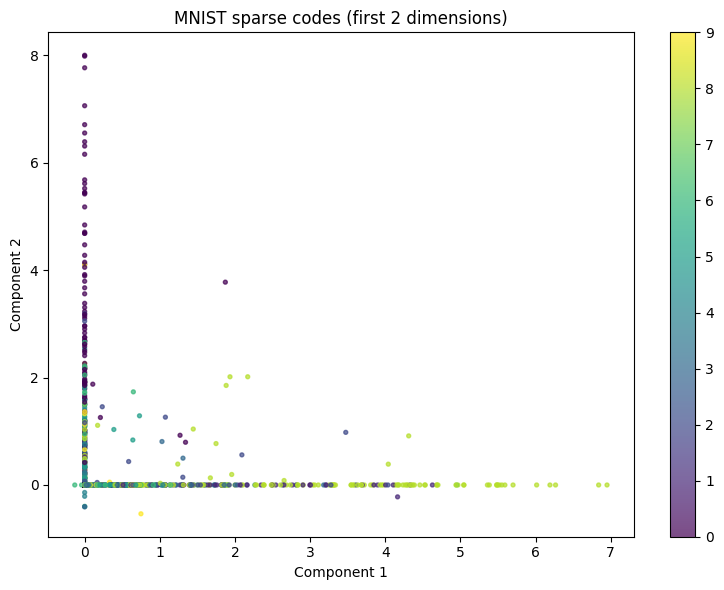

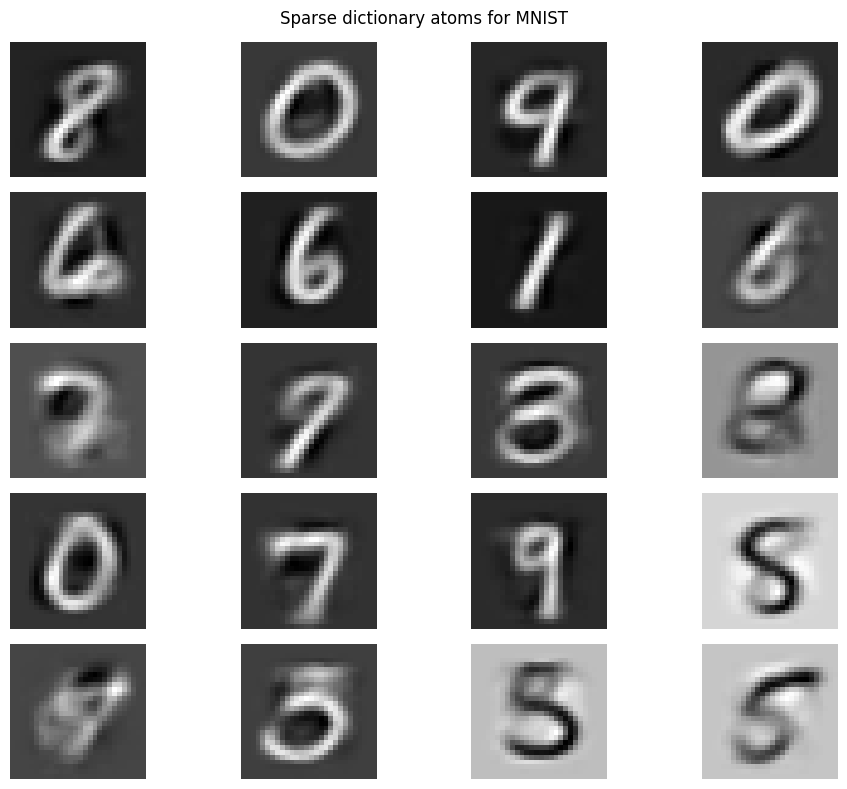

In [65]:
N_DICT_COMPONENTS = 32

alpha = 1
dict_learner = DictionaryLearning(
    n_components=N_DICT_COMPONENTS,
    transform_algorithm="lasso_lars",
    alpha=alpha,
    random_state=RANDOM_STATE,
    max_iter=20
)

mini = 2000
X_mini = X[:mini,:]
y_mini = y[:mini]
Z_sparse = dict_learner.fit_transform(X_mini)
D_sparse = dict_learner.components_

print("lambda for sparsity is", alpha)
print("Sparse code shape:", Z_sparse.shape)
print("Dictionary shape:", D_sparse.shape)
print("Average number of non-zero coefficients per sample:",
      np.mean(np.sum(np.abs(Z_sparse) > 1e-6, axis=1)))

plot_2d_embedding(Z_sparse[:, :2], y_mini, class_names, title=f"{DATASET.upper()} sparse codes (first 2 dimensions)")

show_atoms(
    D_sparse,
    image_shape=image_shape,
    n_show=20,
    title=f"Sparse dictionary atoms for {DATASET.upper()}",
    cmap="gray"
)


lambda for sparsity is 5
Sparse code shape: (2000, 32)
Dictionary shape: (32, 784)
Average number of non-zero coefficients per sample: 1.3395


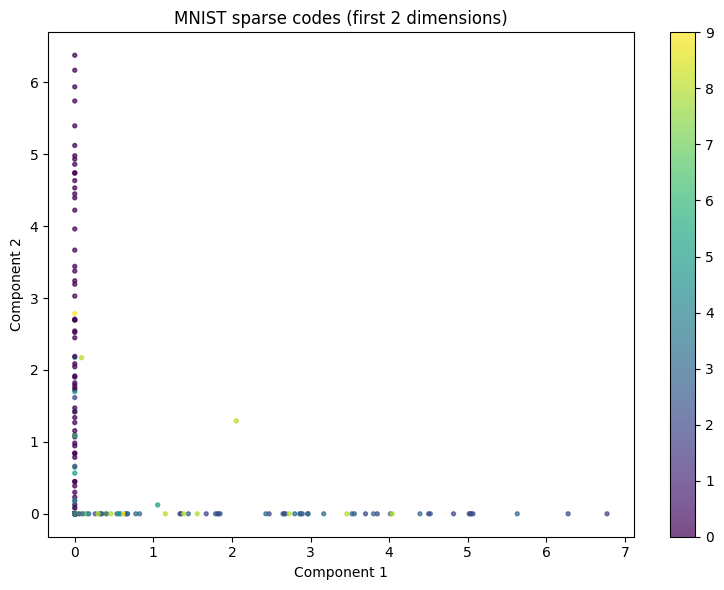

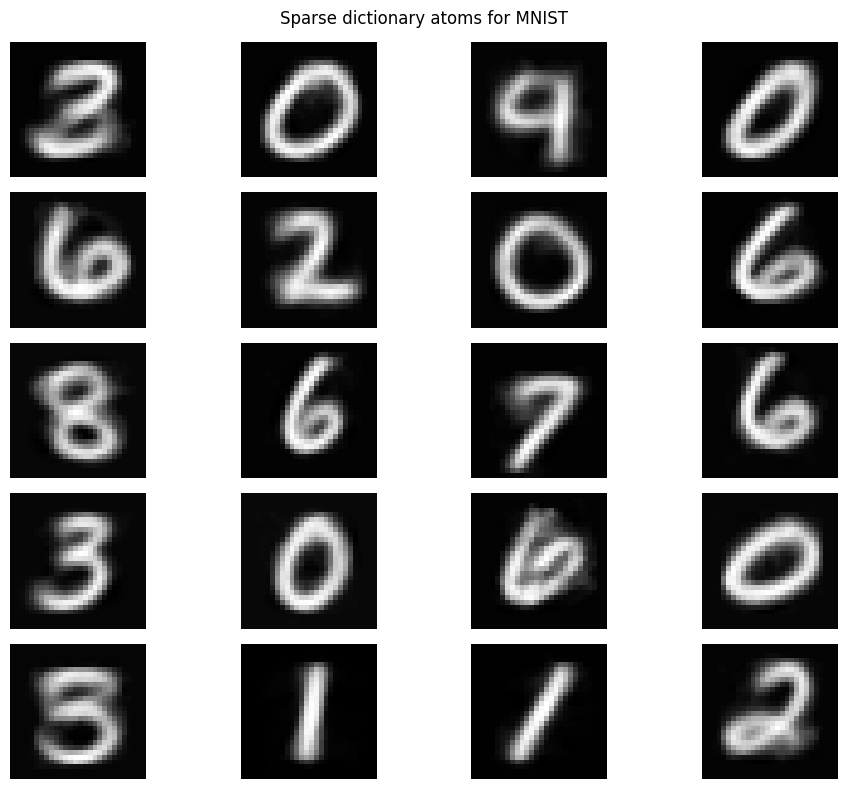

In [67]:
N_DICT_COMPONENTS = 32

alpha = 5
dict_learner = DictionaryLearning(
    n_components=N_DICT_COMPONENTS,
    transform_algorithm="lasso_lars",
    alpha=alpha,
    random_state=RANDOM_STATE,
    max_iter=20
)

mini = 2000
X_mini = X[:mini,:]
y_mini = y[:mini]
Z_sparse = dict_learner.fit_transform(X_mini)
D_sparse = dict_learner.components_

print("lambda for sparsity is", alpha)
print("Sparse code shape:", Z_sparse.shape)
print("Dictionary shape:", D_sparse.shape)
print("Average number of non-zero coefficients per sample:",
      np.mean(np.sum(np.abs(Z_sparse) > 1e-6, axis=1)))

plot_2d_embedding(Z_sparse[:, :2], y_mini, class_names, title=f"{DATASET.upper()} sparse codes (first 2 dimensions)")

show_atoms(
    D_sparse,
    image_shape=image_shape,
    n_show=20,
    title=f"Sparse dictionary atoms for {DATASET.upper()}",
    cmap="gray"
)


/Users/toloosha/miniconda3/envs/ece447/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


CIFAR
X shape: (5000, 1024)
y shape: (5000,)
Pixel range: 0.0 to 1.0


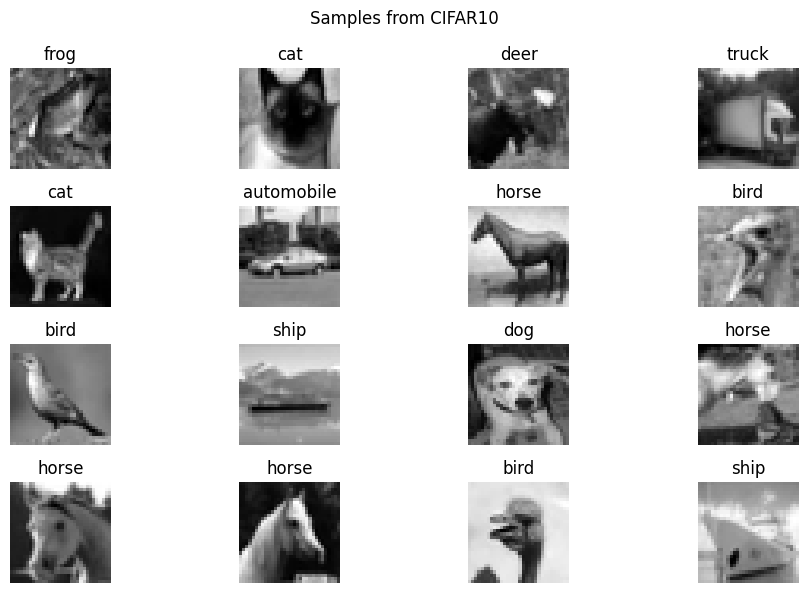

In [73]:
DATASET = "cifar10"      # choose: "mnist" or "cifar10"
N_SAMPLES = 5000       # reduce/increase depending on your machine
RANDOM_STATE = 0
CIFAR_TO_GRAYSCALE = True

np.random.seed(RANDOM_STATE)

X_cifar, y_cifar, images_cifar, class_names_cifar = load_dataset(
    name=DATASET,
    n_samples=N_SAMPLES,
    random_state=RANDOM_STATE,
    cifar_to_grayscale=CIFAR_TO_GRAYSCALE
)

print("CIFAR")
print("X shape:", X_cifar.shape)
print("y shape:", y_cifar.shape)
print("Pixel range:", X.min(), "to", X.max())

show_samples(images_cifar, y_cifar, class_names_cifar, n=16, title=f"Samples from {DATASET.upper()}")


CIFAR
lambda for sparsity is 0.01
Sparse code shape: (2000, 32)
Dictionary shape: (32, 1024)
Average number of non-zero coefficients per sample: 31.5345


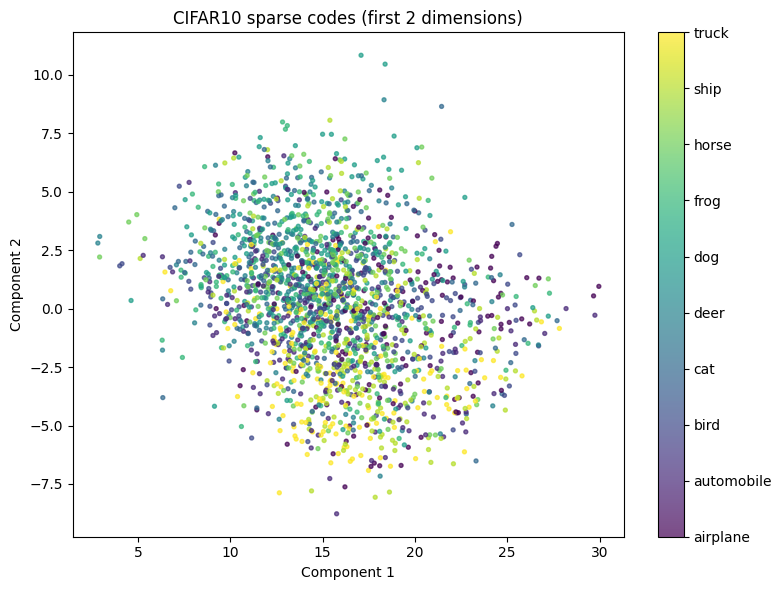

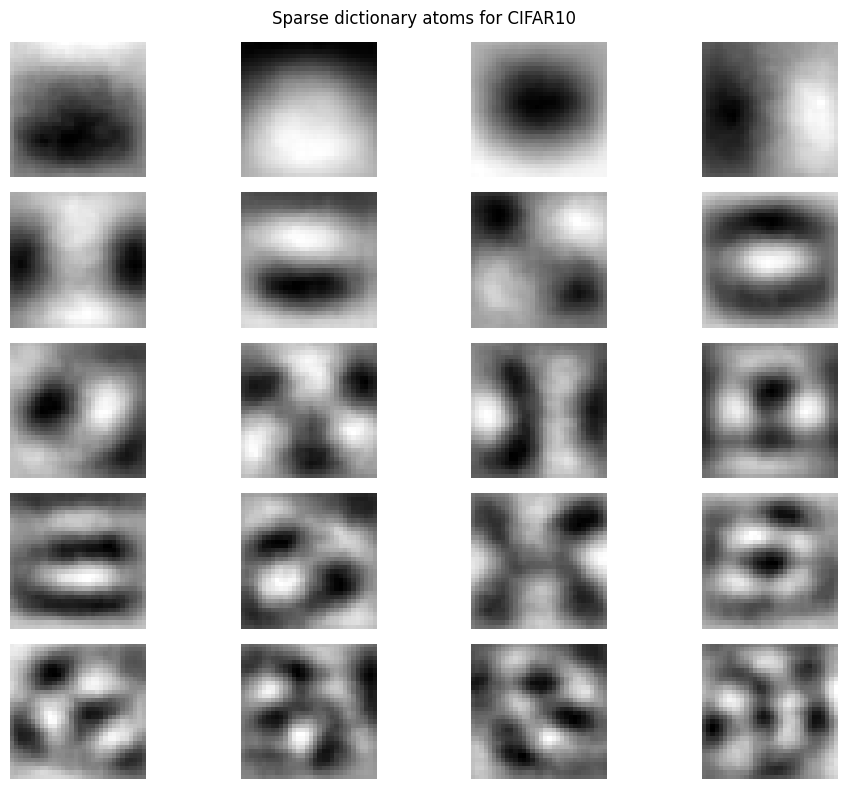

In [74]:
N_DICT_COMPONENTS = 32

alpha = 0.01
dict_learner = DictionaryLearning(
    n_components=N_DICT_COMPONENTS,
    transform_algorithm="lasso_lars",
    alpha=alpha,
    random_state=RANDOM_STATE,
    max_iter=20
)

mini = 2000
X_mini = X_cifar[:mini,:]
y_mini = y_cifar[:mini]
Z_sparse = dict_learner.fit_transform(X_mini)
D_sparse = dict_learner.components_

print("CIFAR")
print("lambda for sparsity is", alpha)
print("Sparse code shape:", Z_sparse.shape)
print("Dictionary shape:", D_sparse.shape)
print("Average number of non-zero coefficients per sample:",
      np.mean(np.sum(np.abs(Z_sparse) > 1e-6, axis=1)))

plot_2d_embedding(Z_sparse[:, :2], y_mini, class_names, title=f"{DATASET.upper()} sparse codes (first 2 dimensions)")

if DATASET == "mnist":
    image_shape = (28, 28)
elif DATASET == "cifar10" and CIFAR_TO_GRAYSCALE:
    image_shape = (32, 32)
else:
    image_shape = (32, 32, 3)
    
show_atoms(
    D_sparse,
    image_shape=image_shape,
    n_show=20,
    title=f"Sparse dictionary atoms for {DATASET.upper()}",
    cmap="gray"
)


CIFAR
lambda for sparsity is 1
Sparse code shape: (2000, 32)
Dictionary shape: (32, 1024)
Average number of non-zero coefficients per sample: 9.2535


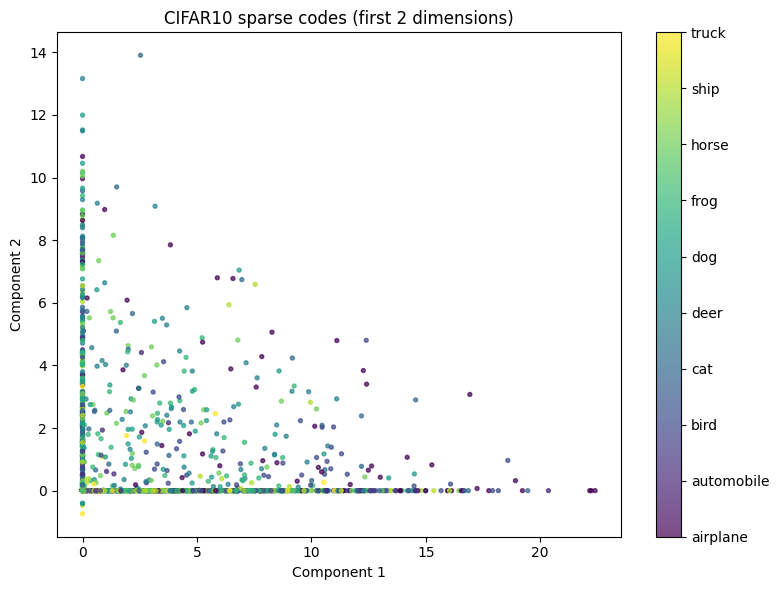

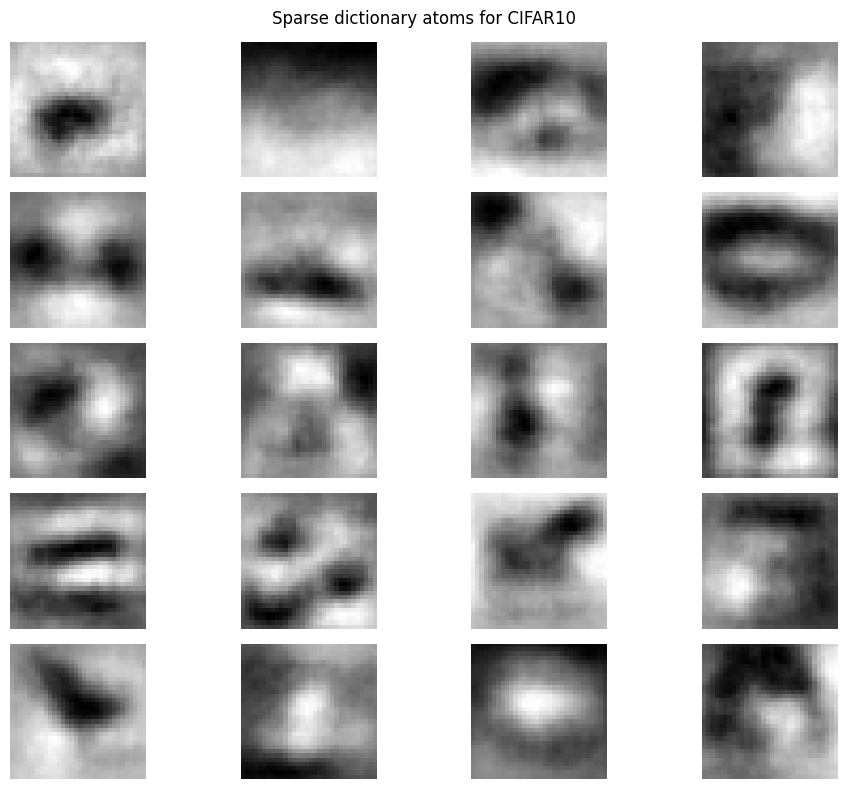

In [75]:
N_DICT_COMPONENTS = 32

alpha = 1
dict_learner = DictionaryLearning(
    n_components=N_DICT_COMPONENTS,
    transform_algorithm="lasso_lars",
    alpha=alpha,
    random_state=RANDOM_STATE,
    max_iter=20
)

mini = 2000
X_mini = X_cifar[:mini,:]
y_mini = y_cifar[:mini]
Z_sparse = dict_learner.fit_transform(X_mini)
D_sparse = dict_learner.components_

print("CIFAR")
print("lambda for sparsity is", alpha)
print("Sparse code shape:", Z_sparse.shape)
print("Dictionary shape:", D_sparse.shape)
print("Average number of non-zero coefficients per sample:",
      np.mean(np.sum(np.abs(Z_sparse) > 1e-6, axis=1)))

plot_2d_embedding(Z_sparse[:, :2], y_mini, class_names, title=f"{DATASET.upper()} sparse codes (first 2 dimensions)")

if DATASET == "mnist":
    image_shape = (28, 28)
elif DATASET == "cifar10" and CIFAR_TO_GRAYSCALE:
    image_shape = (32, 32)
else:
    image_shape = (32, 32, 3)
    
show_atoms(
    D_sparse,
    image_shape=image_shape,
    n_show=20,
    title=f"Sparse dictionary atoms for {DATASET.upper()}",
    cmap="gray"
)


## Extensions

A few useful next steps:

1. **Visualize reconstruction quality**: reconstruct examples from PCA, NMF, or sparse codes


1. **Explore CIFAR more**